# ANOVA, ANCOVA & MANOVA — Comparing Group Means at Scale
*Data 200 · Applied Statistical Analysis · Instructor: Aayush Regmi*

---

In the [Statistics Foundations notebook](StatisticsFoundations.md) we
used a **t-test** to ask: *do these two groups have different means?*
That works beautifully when there are exactly **two** groups. The
moment a third group joins the party, the t-test starts to creak.

This notebook walks the natural progression:

**t-test → one-way ANOVA → two-way ANOVA → ANCOVA → MANOVA.**

Along the way we'll see one of the most useful identities in applied
statistics: **ANOVA is just OLS regression with categorical inputs.**
The same `(X^T X)^{-1} X^T y` machinery from the
[Linear Regression notebook](LinearRegression.md) is doing the work.


## Learning Objectives

By the end of this notebook you should be able to:

1. Recall what a **two-sample t-test** does and why it breaks down for
   three or more groups (the multiple-comparisons problem).
2. Run a **one-way ANOVA** by hand using the SST = SSB + SSW
   decomposition, and interpret the F-statistic.
3. See that ANOVA is **OLS regression with dummy-coded categorical
   variables** — same algorithm, different names.
4. State the **assumptions** of ANOVA and check them in code.
5. Extend to **two-way ANOVA** with two factors and an **interaction
   effect**.
6. Use **ANCOVA** when a continuous covariate (like prior GPA) muddies
   the comparison.
7. Recognise when a **MANOVA** (multiple dependent variables) is
   appropriate — at a conceptual level.


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.graphics.factorplots import interaction_plot
from statsmodels.multivariate.manova import MANOVA

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
rng = np.random.default_rng(42)


## 1. From t-Tests to ANOVA

### Quick recap: the two-sample t-test

Suppose two classrooms write the same exam. Are their average scores
*really* different, or did the gap appear by chance? An **independent
samples t-test** answers exactly that.


In [2]:
class_a = rng.normal(loc=72, scale=8, size=30)   # mean ≈ 72
class_b = rng.normal(loc=78, scale=8, size=30)   # mean ≈ 78

t_stat, p_val = stats.ttest_ind(class_a, class_b)
print(f"Class A mean: {class_a.mean():.2f}")
print(f"Class B mean: {class_b.mean():.2f}")
print(f"t = {t_stat:.3f},  p = {p_val:.4f}")


Class A mean: 72.13
Class B mean: 78.91
t = -4.148,  p = 0.0001


Small p → the means are statistically distinguishable. So far so
good.

### The problem: what if there are *three* classes?

A natural reflex is to run **all pairwise t-tests** — A vs B, A vs C,
B vs C. With one t-test at $\alpha = 0.05$, the chance of a false
alarm is 5%. With three independent tests, the chance that **at least
one** of them is a false alarm is

$$1 - (1 - 0.05)^3 \;\approx\; 14.3\%.$$

With six pairwise tests (four groups), it climbs to **26%**. This is
the **multiple-comparisons problem**: the more tests we run, the more
false discoveries we expect just by luck.


In [3]:
# Show the family-wise error rate exploding as we add comparisons
alpha = 0.05
for k in [1, 2, 3, 6, 10]:
    fwer = 1 - (1 - alpha) ** k
    print(f"{k:>2} independent tests at alpha=0.05  →  family-wise error ≈ {fwer:.1%}")


 1 independent tests at alpha=0.05  →  family-wise error ≈ 5.0%
 2 independent tests at alpha=0.05  →  family-wise error ≈ 9.8%
 3 independent tests at alpha=0.05  →  family-wise error ≈ 14.3%
 6 independent tests at alpha=0.05  →  family-wise error ≈ 26.5%
10 independent tests at alpha=0.05  →  family-wise error ≈ 40.1%


We need **one** test that compares all groups simultaneously, with
the false-positive rate held at 5% overall. That test is **ANOVA**
(*Analysis of Variance*).


## 2. Where ANOVA Shows Up in the Real World

ANOVA is the right tool whenever you want to compare a **numeric
outcome** across **three or more groups**. A few familiar scenes:

- **The farmer.** A farmer tries three fertilizers — A, B, and C — on
  similar plots of land and measures the crop yield from each plot.
  *Does fertilizer choice change average yield, or are the differences
  just luck?*
- **The doctor.** A clinical trial gives three different medicines to
  groups of patients with the same illness and records recovery time
  in days. *Do the medicines actually differ, or could the same gap
  appear from random patient variation?*
- **The educator.** A school tests four teaching methods on different
  classrooms and looks at end-of-term test scores. *Is one method
  reliably better, or just lucky this term?*

Every one of these problems has the same shape: **one numeric outcome,
one categorical "group" variable with several levels.** That is exactly
what one-way ANOVA was designed for.


## 3. One-Way ANOVA — Intuition and Math

### The core idea: split the variation

Take all the yield numbers from the farmer's experiment and forget for
a moment which fertilizer they came from. There is some **total
variation** in those numbers. ANOVA splits that total variation into
two parts:

- **Between-group variation (SSB)** — how far each group's mean is
  from the overall mean. This is the *signal* — variation that the
  group label seems to explain.
- **Within-group variation (SSW)** — how far individual observations
  are from their own group's mean. This is the *noise* — variation
  that has nothing to do with which group you're in.

$$\underbrace{\text{SST}}_{\text{total variation}} \;=\;
\underbrace{\text{SSB}}_{\text{signal: between groups}} \;+\;
\underbrace{\text{SSW}}_{\text{noise: within groups}}$$

If the signal is large compared to the noise, the groups really are
different. ANOVA puts that ratio into a single number — the
**F-statistic**:

$$F \;=\; \frac{\text{SSB} / (k-1)}{\text{SSW} / (n-k)}
\;=\; \frac{\text{between-group variance}}{\text{within-group variance}},$$

where $k$ is the number of groups and $n$ is the total sample size.
Big $F$ → real differences; small $F$ → just noise.


### The fertilizer experiment (synthetic)

Three fertilizers, 20 plots each. Yields are in tons per hectare.


In [4]:
n_per_group = 20
fert_a = rng.normal(loc=5.0, scale=0.6, size=n_per_group)   # baseline
fert_b = rng.normal(loc=5.8, scale=0.6, size=n_per_group)   # a bit better
fert_c = rng.normal(loc=6.2, scale=0.6, size=n_per_group)   # best

fert = pd.DataFrame({
    "yield":      np.concatenate([fert_a, fert_b, fert_c]),
    "fertilizer": np.repeat(["A", "B", "C"], n_per_group),
})
fert.head()


,yield,fertilizer
0,3.990278,A
1,4.799069,A
2,5.097652,A
3,5.351733,A
4,5.426736,A


/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_17973/561516898.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fert, x="fertilizer", y="yield",


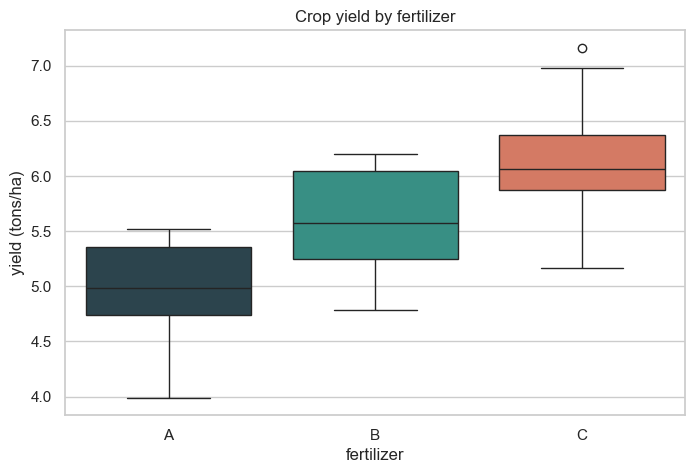

In [5]:
sns.boxplot(data=fert, x="fertilizer", y="yield",
            palette=["#264653", "#2a9d8f", "#e76f51"])
plt.title("Crop yield by fertilizer")
plt.ylabel("yield (tons/ha)"); plt.show()


### Quick-and-dirty ANOVA — `scipy.stats.f_oneway`

In [6]:
f_stat, p_val = stats.f_oneway(fert_a, fert_b, fert_c)
print(f"F-statistic : {f_stat:.3f}")
print(f"p-value     : {p_val:.4g}")


F-statistic : 32.859
p-value     : 3.226e-10


A large F and a tiny p — fertilizer choice **does** explain variation
in yield. But the bare numbers don't show *how* ANOVA arrived at this
answer. Let's compute the same F by hand from the SSB / SSW formulas.


In [7]:
grand_mean = fert["yield"].mean()
k = fert["fertilizer"].nunique()
n = len(fert)

group_means = fert.groupby("fertilizer")["yield"].mean()
group_sizes = fert.groupby("fertilizer")["yield"].size()

# Between-group sum of squares
ssb = (group_sizes * (group_means - grand_mean) ** 2).sum()
# Within-group sum of squares
ssw = ((fert["yield"] - fert.groupby("fertilizer")["yield"].transform("mean")) ** 2).sum()
sst = ((fert["yield"] - grand_mean) ** 2).sum()

f_manual = (ssb / (k - 1)) / (ssw / (n - k))

print(f"SSB (between groups): {ssb:.3f}")
print(f"SSW (within groups) : {ssw:.3f}")
print(f"SST (total)         : {sst:.3f}")
print(f"Sanity check: SSB + SSW = {ssb + ssw:.3f}  (should equal SST)")
print(f"\nManual F-statistic  : {f_manual:.3f}  (matches scipy)")


SSB (between groups): 14.172
SSW (within groups) : 12.292
SST (total)         : 26.465
Sanity check: SSB + SSW = 26.465  (should equal SST)

Manual F-statistic  : 32.859  (matches scipy)


## 4. ANOVA *Is* OLS Regression

Here's the punchline that often surprises students:

> **One-way ANOVA is exactly an OLS regression with the categorical
> group encoded as dummy variables.**

In the [Linear Regression notebook](LinearRegression.md) OLS estimated
$(\beta_0, \beta_1, \ldots)$ for **continuous** predictors. With a
categorical predictor, the same OLS estimates the **mean of each
group**. Same machine, different inputs.

Let's see it. statsmodels' `ols` with the formula
`yield ~ C(fertilizer)` automatically dummy-encodes fertilizer and
fits the regression.


In [8]:
model = ols("Q('yield') ~ C(fertilizer)", data=fert).fit()
print(model.summary().tables[1])


                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.9442      0.104     47.614      0.000       4.736       5.152
C(fertilizer)[T.B]     0.6432      0.147      4.380      0.000       0.349       0.937
C(fertilizer)[T.C]     1.1891      0.147      8.098      0.000       0.895       1.483


Read the coefficient table:

- `Intercept` ≈ mean of fertilizer **A** (the baseline).
- `C(fertilizer)[T.B]` = mean(B) − mean(A).
- `C(fertilizer)[T.C]` = mean(C) − mean(A).

Compare those numbers to the group means we computed earlier:


In [9]:
print("Group means:")
print(group_means)
print(f"\nFitted intercept (should equal mean A): {model.params['Intercept']:.3f}")
print(f"B - A   from coefficient: {model.params['C(fertilizer)[T.B]']:.3f}")
print(f"B - A   from means      : {group_means['B'] - group_means['A']:.3f}")


Group means:
fertilizer
A    4.944217
B    5.587460
C    6.133362
Name: yield, dtype: float64

Fitted intercept (should equal mean A): 4.944
B - A   from coefficient: 0.643
B - A   from means      : 0.643


### The ANOVA table from the same OLS fit

`anova_lm` re-summarises the same fit as the classic ANOVA
decomposition (SSB, SSW, F, p):


In [10]:
anova_lm(model)


,df,sum_sq,mean_sq,F,PR(>F)
C(fertilizer),2.0,14.172244,7.086122,32.858521,3.225851e-10
Residual,57.0,12.292366,0.215656,NaN,NaN


The F-statistic and p-value are *identical* to the ones from
`scipy.stats.f_oneway` and our hand calculation. ANOVA and OLS are
two readouts of the same underlying fit.

### What the design matrix looks like

To make the dummy encoding visible, here are the first few rows of
the design matrix `X` that statsmodels actually solved
$\hat\beta = (X^\top X)^{-1} X^\top y$ for:


In [11]:
X = pd.DataFrame(model.model.exog,
                 columns=model.model.exog_names)
X.assign(fertilizer=fert["fertilizer"].values).head(8)


,Intercept,C(fertilizer)[T.B],C(fertilizer)[T.C],fertilizer
0,1.0,0.0,0.0,A
1,1.0,0.0,0.0,A
2,1.0,0.0,0.0,A
3,1.0,0.0,0.0,A
4,1.0,0.0,0.0,A
5,1.0,0.0,0.0,A
6,1.0,0.0,0.0,A
7,1.0,0.0,0.0,A


Fertilizer A → both dummies are 0 → only the intercept fires →
predicted yield = mean(A). Fertilizer B → dummy B is 1 → predicted
yield = mean(A) + (mean(B) − mean(A)) = mean(B). And so on. The
regression coefficients **are** the group means in disguise.


## 5. ANOVA Assumptions

Like every statistical test, ANOVA is built on assumptions. The
p-value is only trustworthy if these hold:

1. **Independence** — observations are unrelated. (Same plot measured
   twice would violate this; so would students copying answers.)
2. **Normality of residuals** — the residuals from the fit should be
   approximately normally distributed.
3. **Homogeneity of variance** ("homoscedasticity") — all groups
   should have similar spread.

Two quick code checks below.


In [12]:
# (a) Normality of residuals — Shapiro-Wilk
residuals = model.resid
shapiro_W, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk : W = {shapiro_W:.3f}, p = {shapiro_p:.3f}  (large p → looks normal)")

# (b) Equal variances across groups — Levene's test
levene_W, levene_p = stats.levene(fert_a, fert_b, fert_c)
print(f"Levene       : W = {levene_W:.3f}, p = {levene_p:.3f}  (large p → variances look equal)")


Shapiro-Wilk : W = 0.979, p = 0.391  (large p → looks normal)
Levene       : W = 0.046, p = 0.955  (large p → variances look equal)


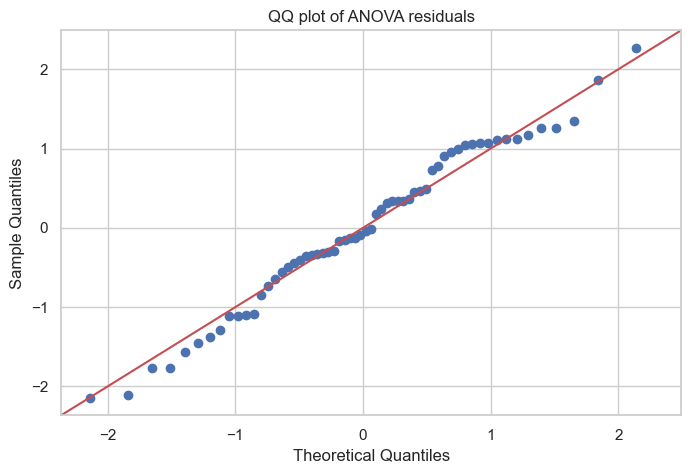

In [13]:
# A QQ plot of residuals — points close to the line ⇒ approximately normal
sm.qqplot(residuals, line="45", fit=True)
plt.title("QQ plot of ANOVA residuals"); plt.show()


**If assumptions are violated:**

- Variances clearly unequal? Use **Welch's ANOVA**
  (`scipy.stats.f_oneway` has a Welch variant via
  `pingouin.welch_anova`).
- Residuals strongly non-normal? Try the non-parametric
  **Kruskal-Wallis test** (`scipy.stats.kruskal`).


## 6. Two-Way ANOVA — Two Factors at Once

One-way ANOVA had **one** grouping variable. Real experiments often
vary **two** things at once. Two-way ANOVA lets us ask three questions
from a single fit:

1. Is there a main effect of factor A?
2. Is there a main effect of factor B?
3. Is there an **interaction** — does the effect of A depend on B?

### Example: medicine × gender on recovery time

Three medicines, two genders. We synthesise data where medicine C
works particularly well for one gender — i.e. there is an interaction.


In [14]:
n_each = 25
rows = []
# Mean recovery time (days) for each (medicine, gender) cell
cell_means = {
    ("A", "F"): 9.0, ("A", "M"): 9.2,
    ("B", "F"): 7.5, ("B", "M"): 7.7,
    ("C", "F"): 5.5, ("C", "M"): 7.0,    # interaction lives here
}
for (med, gen), mu in cell_means.items():
    rows.append(pd.DataFrame({
        "recovery": rng.normal(loc=mu, scale=1.2, size=n_each),
        "medicine": med,
        "gender":   gen,
    }))
med = pd.concat(rows, ignore_index=True)
med.head()


,recovery,medicine,gender
0,7.771803,A,F
1,9.215131,A,F
2,9.263996,A,F
3,10.631025,A,F
4,10.002133,A,F


In [15]:
# Two-way ANOVA with interaction term
model2 = ols("recovery ~ C(medicine) + C(gender) + C(medicine):C(gender)",
             data=med).fit()
anova_lm(model2, typ=2)


,sum_sq,df,F,PR(>F)
C(medicine),206.911857,2.0,67.194064,2.439205e-21
C(gender),14.727458,1.0,9.565404,2.381881e-03
C(medicine):C(gender),28.758802,2.0,9.339343,1.535650e-04
Residual,221.710860,144.0,NaN,NaN


Read the table:

- **C(medicine)** — significant main effect: medicines differ on
  average.
- **C(gender)** — main effect of gender (small here).
- **C(medicine):C(gender)** — *interaction*: the *gap between medicines
  is not the same for both genders*. The interaction plot makes this
  visible.


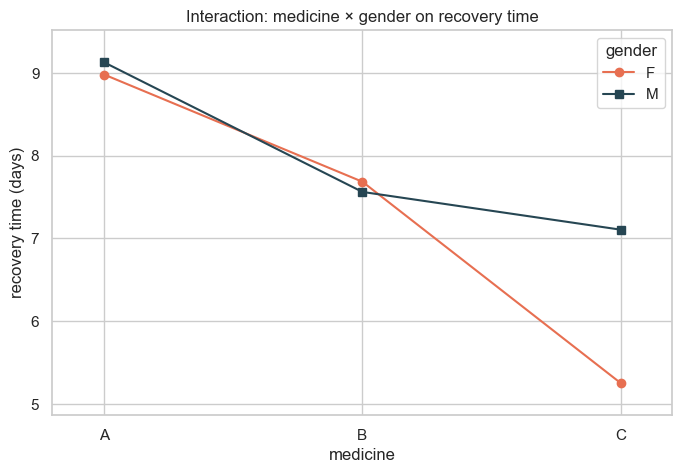

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
interaction_plot(
    x=med["medicine"], trace=med["gender"], response=med["recovery"],
    colors=["#e76f51", "#264653"], markers=["o", "s"], ax=ax,
)
ax.set_ylabel("recovery time (days)")
ax.set_title("Interaction: medicine × gender on recovery time")
plt.show()


Non-parallel lines ⇒ interaction. Medicine C works dramatically
better for one gender than the other.

### A second two-way example: fertilizer × watering frequency

Two fertilizers, two watering schedules — does one combination beat
the rest?


In [17]:
n_each = 18
rows = []
for (f, w), mu in {
    ("A", "daily"):  5.5, ("A", "weekly"): 5.0,
    ("B", "daily"):  6.4, ("B", "weekly"): 5.4,
}.items():
    rows.append(pd.DataFrame({
        "yield":      rng.normal(loc=mu, scale=0.5, size=n_each),
        "fertilizer": f,
        "watering":   w,
    }))
farm = pd.concat(rows, ignore_index=True)

model_farm = ols("Q('yield') ~ C(fertilizer) + C(watering) + C(fertilizer):C(watering)",
                 data=farm).fit()
anova_lm(model_farm, typ=2)


,sum_sq,df,F,PR(>F)
C(fertilizer),10.717942,1.0,42.867108,9.185158e-09
C(watering),17.470879,1.0,69.875921,4.881116e-12
C(fertilizer):C(watering),1.982103,1.0,7.927550,6.364605e-03
Residual,17.001847,68.0,NaN,NaN


Significant interaction ⇒ the *best* fertilizer depends on watering
schedule. That is a finding pure one-way ANOVA could never have
surfaced.


## 7. ANCOVA — When a Continuous Covariate Muddies the Picture

### Why one-way ANOVA can mislead

Suppose we want to compare **three teaching methods** on end-of-term
test scores. We run a one-way ANOVA on `score ~ C(method)` and find
that the methods differ.

But there's a confounder: students assigned to different methods may
have started with different **prior GPAs**. A method that happened to
get the stronger students looks better than it really is.

**ANCOVA** (Analysis of *Covariance*) handles this by adding the
covariate to the model:

$$\text{score} \;=\; \beta_0 \;+\; \beta_1 \,\text{prior\_gpa}
\;+\; \text{group dummies} \;+\; \varepsilon.$$

The continuous covariate is "regressed out" of the score before group
means are compared. We end up asking the cleaner question: *holding
prior GPA constant, do the methods differ?*


### Synthetic student dataset

We deliberately introduce a confound: method C tends to be assigned to
students with higher prior GPA. So a naive one-way ANOVA will
**overstate** how good method C is.


In [18]:
n_each = 30
data = []
method_effect = {"A": 0.0, "B": 1.0, "C": 1.5}
method_gpa    = {"A": 2.8, "B": 3.0, "C": 3.4}    # confounded with method

for m in ["A", "B", "C"]:
    prior = rng.normal(loc=method_gpa[m], scale=0.3, size=n_each).clip(1, 4)
    score = 60 + 8 * prior + method_effect[m] + rng.normal(scale=3, size=n_each)
    data.append(pd.DataFrame({"score": score, "prior_gpa": prior, "method": m}))
students = pd.concat(data, ignore_index=True)
students.head()


,score,prior_gpa,method
0,85.143263,2.821610,A
1,85.918797,2.924167,A
2,87.941253,3.284863,A
3,84.431187,2.181029,A
4,80.365867,2.622669,A


**Step 1 — Naive one-way ANOVA (ignoring prior GPA):**

In [19]:
naive = ols("score ~ C(method)", data=students).fit()
print("Naive one-way ANOVA (no covariate):\n")
print(anova_lm(naive))
print("\nMethod-effect coefficients:")
print(naive.params)


Naive one-way ANOVA (no covariate):

             df       sum_sq     mean_sq          F        PR(>F)
C(method)   2.0   478.315700  239.157850  18.393294  2.176639e-07
Residual   87.0  1131.213011   13.002448        NaN           NaN

Method-effect coefficients:
Intercept         82.654636
C(method)[T.B]     2.261608
C(method)[T.C]     5.611834
dtype: float64


**Step 2 — ANCOVA (adding prior GPA as a covariate):**

In [20]:
ancova = ols("score ~ prior_gpa + C(method)", data=students).fit()
print("ANCOVA (covariate-adjusted):\n")
print(anova_lm(ancova, typ=2))
print("\nMethod-effect coefficients (controlling for prior GPA):")
print(ancova.params)


ANCOVA (covariate-adjusted):

               sum_sq    df          F        PR(>F)
C(method)   54.356163   2.0   2.733619  7.063404e-02
prior_gpa  276.187150   1.0  27.779388  9.957508e-07
Residual   855.025861  86.0        NaN           NaN

Method-effect coefficients (controlling for prior GPA):
Intercept         65.308069
C(method)[T.B]     1.631168
C(method)[T.C]     2.131906
prior_gpa          6.096443
dtype: float64


Compare the two `C(method)[T.C]` coefficients. The naive ANOVA
reports a much bigger gap between methods A and C than ANCOVA does —
because the naive version is partly measuring the prior-GPA
advantage, not the method itself. ANCOVA strips that out.


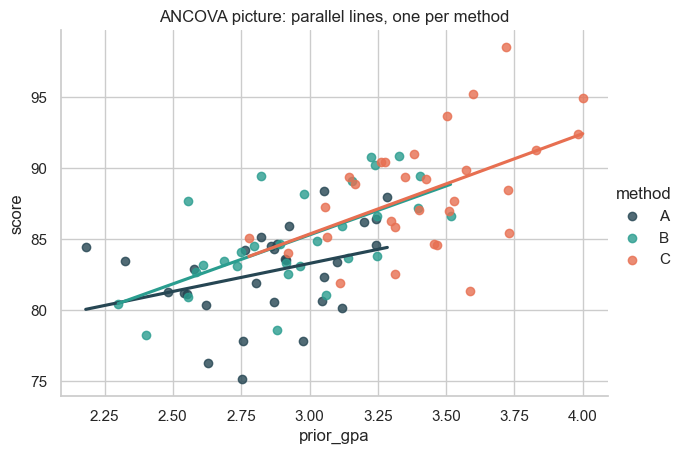

In [21]:
# Visualise: regression lines per method, after adjusting for prior GPA
sns.lmplot(data=students, x="prior_gpa", y="score", hue="method",
           palette=["#264653", "#2a9d8f", "#e76f51"], height=4.5, aspect=1.4,
           ci=None)
plt.title("ANCOVA picture: parallel lines, one per method")
plt.show()


Three roughly parallel lines, slightly shifted vertically. The
vertical shift between lines = the *true* method effect, after the
shared slope (prior GPA) has been accounted for.


## 8. MANOVA — Multiple Outcomes at Once (briefly)

ANOVA / ANCOVA test how groups differ on **one** dependent variable.
**MANOVA** (*Multivariate ANOVA*) tests how groups differ on **two or
more dependent variables simultaneously**.

Why bother? Because two outcomes might *individually* look unaffected
but show a clear group difference *together* (or vice versa). MANOVA
uses the joint distribution.

### Tiny example

Three teaching methods, two outcomes per student: **test score** and
**homework completion %**. We ask: *does the choice of method affect
this pair of outcomes jointly?*


In [22]:
n_each = 30
rows = []
cells = {
    "A": (72,  60),
    "B": (78,  75),
    "C": (80,  85),
}
for m, (score_mu, hw_mu) in cells.items():
    rows.append(pd.DataFrame({
        "score":     rng.normal(loc=score_mu, scale=6, size=n_each),
        "homework":  rng.normal(loc=hw_mu,    scale=8, size=n_each).clip(0, 100),
        "method":    m,
    }))
df_m = pd.concat(rows, ignore_index=True)

manova = MANOVA.from_formula("score + homework ~ method", data=df_m)
print(manova.mv_test())


                   Multivariate linear model
                                                               
---------------------------------------------------------------
       Intercept         Value  Num DF  Den DF  F Value  Pr > F
---------------------------------------------------------------
          Wilks' lambda  0.0163 2.0000 86.0000 2599.1085 0.0000
         Pillai's trace  0.9837 2.0000 86.0000 2599.1085 0.0000
 Hotelling-Lawley trace 60.4444 2.0000 86.0000 2599.1085 0.0000
    Roy's greatest root 60.4444 2.0000 86.0000 2599.1085 0.0000
---------------------------------------------------------------
                                                               
---------------------------------------------------------------
           method         Value  Num DF  Den DF  F Value Pr > F
---------------------------------------------------------------
            Wilks' lambda 0.3386 4.0000 172.0000 30.8931 0.0000
           Pillai's trace 0.6670 4.0000 174.0000 21.7652 0.

MANOVA reports four classical test statistics — **Wilks' Lambda**,
**Pillai's Trace**, **Hotelling-Lawley Trace**, **Roy's Greatest
Root**. They each summarise the same underlying question ("do the
groups differ across all outcomes jointly?") in a slightly different
way. For a beginner the only thing to read is the **p-value column**:
if it's small for the `method` row, the groups differ on the
score-homework pair taken together.

We won't go further than this — full multivariate analysis is its own
course. Just remember: **MANOVA is the natural next step when you have
more than one dependent variable**.


## 9. Key Takeaways

1. **Pairwise t-tests don't scale.** With $k$ groups you'd run
   $\binom{k}{2}$ tests, and the false-positive rate inflates fast.
   ANOVA is the single, well-calibrated alternative.
2. **One-way ANOVA splits variance** into between-group (signal) and
   within-group (noise) and reports their ratio as the F-statistic.
3. **ANOVA is OLS in disguise.** statsmodels' `ols("y ~ C(group)")`
   gives the same answer — the group label becomes dummy variables
   and the same $(X^\top X)^{-1} X^\top y$ does the work.
4. **Two-way ANOVA** adds a second factor and surfaces **interaction
   effects** — situations where the influence of one factor depends
   on the other.
5. **ANCOVA** keeps a continuous **covariate** in the model so group
   comparisons are fair. "Holding prior GPA constant, do methods
   differ?"
6. **MANOVA** is for **multiple dependent variables** at once. Use
   when the outcomes are correlated and you want a joint test.
7. **Always check the assumptions**: independence, residual normality,
   and equal variances — and know the fallback tests when they fail.


## 10. Practice Exercises

1. **Pairwise vs. ANOVA.** Generate four groups with means
   $\mu = (10, 10, 10, 10)$ (i.e. *no real difference*). Run all six
   pairwise t-tests at $\alpha = 0.05$. Repeat the whole simulation
   1000 times and report the fraction of simulations where **at least
   one** pairwise test was significant. Compare with a single ANOVA
   on the same data.
2. **Two-way ANOVA on fertilizer × watering.** Extend the §6 farm
   dataset with a *third* fertilizer (C) and re-fit. Is the
   interaction still significant? Plot it.
3. **ANCOVA on a different covariate.** Re-do the §7 student
   experiment but let `hours_studied` be the covariate (instead of
   prior GPA). Confound the methods with study hours, then show how
   ANCOVA separates the true method effect from the study-hours
   effect.
